# 03 — Phase 1 Screening Analysis
Analisis hasil 128 eksperimen Phase 1, penetapan Phase 2 groups.

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
import warnings
warnings.filterwarnings("ignore")

df_results = pd.read_csv("phase1_screening_results.csv")
df_analysis = pd.read_csv("phase1_screening_analysis.csv")
print("Phase 1 results:", df_results.shape)
print("Screening analysis:", df_analysis.shape)
print("Models:", df_results['Model'].unique().tolist())
print("Windows:", df_results['Window'].unique().tolist())


Phase 1 results: (256, 12)
Screening analysis: (240, 8)
Models: ['RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']
Windows: [30, 120]


## 1. Overview: MAPE per Model × Window

In [11]:

# Best result per model × window (covariate = best performer)
mape_col = 'MAPE_mean' if 'MAPE_mean' in df_results.columns else 'MAPE'
pivot = df_results.groupby(['Model', 'Window'])[mape_col].min().unstack()
print("Best MAPE per Model × Window:")
print(pivot.round(4))


Best MAPE per Model × Window:
Window           30      120
Model                       
ExtraTrees    0.6581  0.6586
LightGBM      0.6987  0.6960
RandomForest  0.6599  0.6612
XGBoost       0.6978  0.6954


## 2. Screening Pass/Fail Summary

In [7]:

pass_counts = (
    df_analysis[df_analysis['Passed']]
    .groupby('Covariate').size()
    .rename('pass_count')
    .sort_values(ascending=False)
    .reset_index()
)
pass_counts['max_combos'] = df_analysis['Model'].nunique() * df_analysis['Window'].nunique()
pass_counts['pass_rate_pct'] = (pass_counts['pass_count'] / pass_counts['max_combos'] * 100).round(1)
print(pass_counts.to_string(index=False))


      Covariate  pass_count  max_combos  pass_rate_pct
         USDIDR           8           8          100.0
           Gold           7           8           87.5
         Silver           7           8           87.5
            WTI           7           8           87.5
        BI_Rate           5           8           62.5
            CPI           5           8           62.5
         Copper           5           8           62.5
            GDP           4           8           50.0
             M2           4           8           50.0
      NPL_Ratio           4           8           50.0
         Nickel           4           8           50.0
            STI           4           8           50.0
US_Treasury_10Y           3           8           37.5
            Tin           2           8           25.0


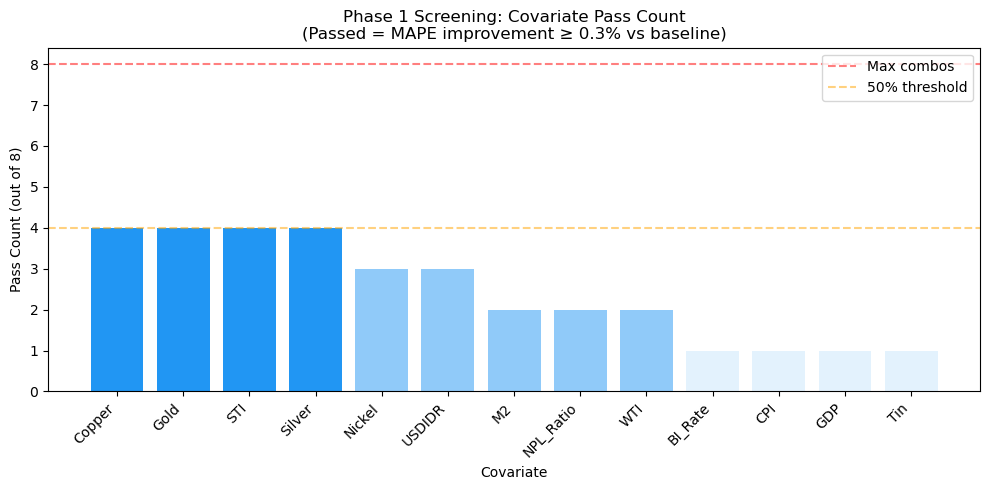

Saved: plot_phase1_screening_summary.png


In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if x >= 4 else '#90CAF9' if x >= 2 else '#E3F2FD' for x in pass_counts['pass_count']]
bars = ax.bar(pass_counts['Covariate'], pass_counts['pass_count'], color=colors)
ax.axhline(y=pass_counts['max_combos'].iloc[0], color='red', linestyle='--', alpha=0.5, label='Max combos')
ax.axhline(y=pass_counts['max_combos'].iloc[0]*0.5, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
ax.set_xlabel("Covariate")
ax.set_ylabel("Pass Count (out of 8)")
ax.set_title("Phase 1 Screening: Covariate Pass Count\n(Passed = MAPE improvement ≥ 0.3% vs baseline)")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plot_phase1_screening_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_phase1_screening_summary.png")


## 3. Heatmap: MAPE Improvement per Covariate × Model

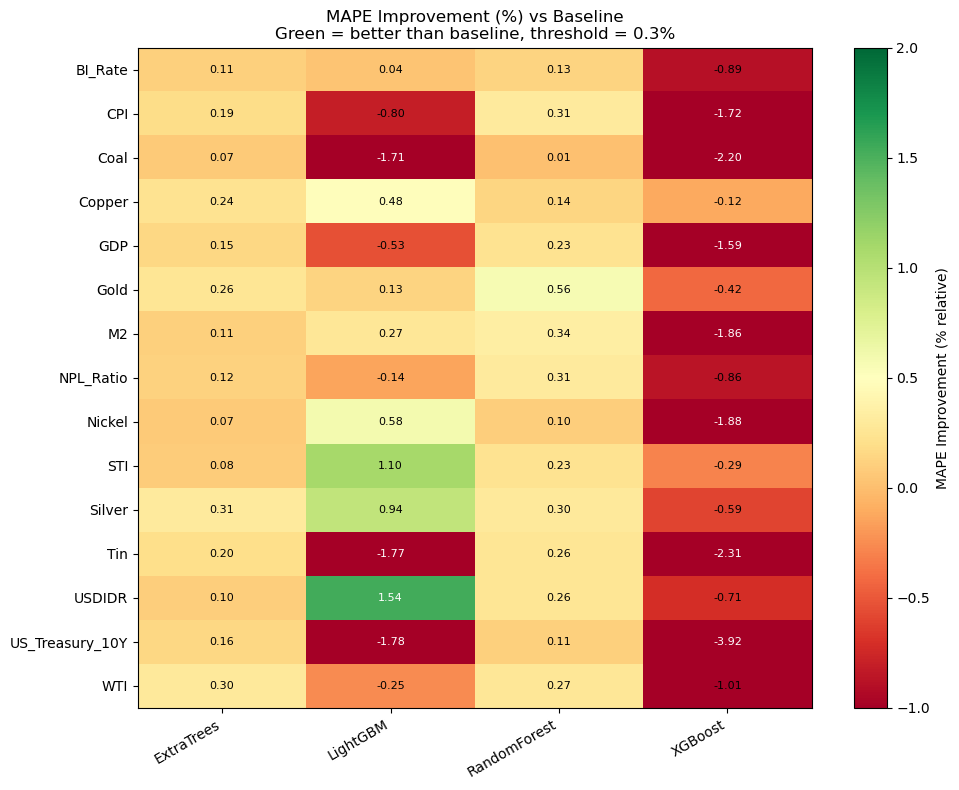

Saved: plot_phase1_heatmap.png


In [5]:

# Pivot: covariate × model, value = mean improvement_pct across windows
heatmap_data = df_analysis.pivot_table(
    values='Improvement_pct', index='Covariate', columns='Model', aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=2)
plt.colorbar(im, ax=ax, label='MAPE Improvement (% relative)')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if abs(val) < 1.5 else 'white')
ax.set_title("MAPE Improvement (%) vs Baseline\nGreen = better than baseline, threshold = 0.3%")
plt.tight_layout()
plt.savefig("plot_phase1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_phase1_heatmap.png")


## 4. Define Phase 2 Groups

In [6]:

MACRO_VARS = ['BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'GDP', 'US_Treasury_10Y']
COMMODITY_VARS = ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'WTI']
REGIONAL_VARS = ['STI']

# Threshold: passed in >= 2 model×window combos (25% of 8)
THRESHOLD_PASS = 2
passed_covariates = pass_counts[pass_counts['pass_count'] >= THRESHOLD_PASS]['Covariate'].tolist()
print(f"Covariates passing threshold (>= {THRESHOLD_PASS} combos):", passed_covariates)

sig_macro = [v for v in MACRO_VARS if v in passed_covariates]
sig_commodity = [v for v in COMMODITY_VARS if v in passed_covariates]
sig_regional = [v for v in REGIONAL_VARS if v in passed_covariates]
sig_all = sig_macro + sig_commodity + sig_regional

GROUP_COVARIATES = {}
if sig_macro:
    GROUP_COVARIATES['Sig_Macro'] = sig_macro
if sig_commodity:
    GROUP_COVARIATES['Sig_Commodity'] = sig_commodity
if sig_regional:
    GROUP_COVARIATES['Sig_Regional'] = sig_regional
if len(sig_all) > 1:
    GROUP_COVARIATES['Sig_All'] = sig_all

print("\nPhase 2 Groups:")
for k, v in GROUP_COVARIATES.items():
    print(f"  {k}: {v}")


Covariates passing threshold (>= 2 combos): ['Copper', 'Gold', 'STI', 'Silver', 'Nickel', 'USDIDR', 'M2', 'NPL_Ratio', 'WTI']

Phase 2 Groups:
  Sig_Macro: ['M2', 'NPL_Ratio', 'USDIDR']
  Sig_Commodity: ['Copper', 'Nickel', 'Silver', 'Gold', 'WTI']
  Sig_Regional: ['STI']
  Sig_All: ['M2', 'NPL_Ratio', 'USDIDR', 'Copper', 'Nickel', 'Silver', 'Gold', 'WTI', 'STI']


In [7]:

import os
os.makedirs("saved_models", exist_ok=True)
joblib.dump(GROUP_COVARIATES, "saved_models/phase2_groups.joblib")
print("Saved: saved_models/phase2_groups.joblib")
print(f"Total Phase 2 experiments: {len(GROUP_COVARIATES)} groups × 4 models × 2 windows = {len(GROUP_COVARIATES)*4*2}")


Saved: saved_models/phase2_groups.joblib
Total Phase 2 experiments: 4 groups × 4 models × 2 windows = 32
